In [1]:
from pandas import DataFrame
import numpy as np
from lets_plot import *

LetsPlot.setup_html()

In [2]:
# Generate random data.
np.random.seed(123)
data = DataFrame(dict(
    cond=np.repeat(['A','B'], 200),
    rating=np.concatenate((np.random.normal(0, 1, 200), np.random.normal(.8, 1, 200)))
))

# Create plot and store it variable 'p'. 
p = ggplot(data, aes(x='rating')) + geom_histogram(binwidth=.5, colour="black", fill="white")

# Find the mean of each group and add a layer of vertical lines marking the means.
cdat = data.groupby(['cond'], as_index=False).mean()
p += geom_vline(data=cdat, mapping=aes(xintercept='rating'), linetype="dashed", size=1, colour="red")

# Group by `cond` and show separately.
p += facet_grid(None, 'cond') + ggsize(500, 250)

### Export SVG to file

In [3]:
ggsave(p, "hist.svg")

'D:\\Projects\\DataPad\\Subprojects\\LetsPlotDocs\\lets-plot-docs-fork\\source\\examples\\cookbook\\lets-plot-images\\hist.svg'

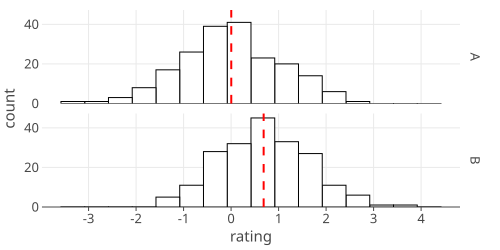

In [4]:
# Load and display saved SVG
from IPython.display import SVG

display(SVG(filename="lets-plot-images/hist.svg"))

### Export HTML to file

By default, when exporting HTML, `ggsave` wraps the HTML of the plot in an `iframe` that matches the size of the plot.

In [5]:
ggsave(p, "hist.html")

'D:\\Projects\\DataPad\\Subprojects\\LetsPlotDocs\\lets-plot-docs-fork\\source\\examples\\cookbook\\lets-plot-images\\hist.html'

In [6]:
# Load and display saved HTML
from IPython.display import HTML

display(HTML(filename="lets-plot-images/hist.html"))

Use the `iframe=False` option to only export the HTML of the plot, without adding an `iframe`.

In [7]:
fname = ggsave(p, "hist_no_iframe.html", iframe=False)
display(HTML(filename=fname))

In [8]:
!rm -rf lets-plot-images